### Read SNOWPACK Output at TRAM with HRRR-AK WY2020-WY2025

created by Cassie Lumbrazo\
last updated: May 2026\
run location: UAS linux\
python environment: **xarray**

In [2]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy
import os

In [3]:
pwd

'/home/cassie/python/repos/snow_modeling_point/sites/tram'

# Open Data and Model Simulations

## Function for Reading SMET Files 

In [4]:
def read_smet(filepath):
    header = {}
    fields = None
    data_start = None

    # Read file and parse header
    with open(filepath, "r") as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        line = line.strip()

        # Detect fields line
        if line.startswith("fields"):
            fields = line.split("=")[1].strip().split()

        # Detect start of data
        if line == "[DATA]":
            data_start = i + 1
            break

        # Parse header key-value pairs
        if "=" in line and not line.startswith("["):
            key, value = line.split("=", 1)
            header[key.strip()] = value.strip()

    if fields is None:
        raise ValueError("No 'fields' line found in SMET header.")
    if data_start is None:
        raise ValueError("No [DATA] section found.")

    # Read data into DataFrame
    df = pd.read_csv(
        filepath,
        skiprows=data_start,
        delim_whitespace=True,
        names=fields,
        parse_dates=["timestamp"]
    )

    # Set timestamp as index
    df = df.set_index("timestamp")

    # Convert to xarray
    ds = xr.Dataset.from_dataframe(df)

    return ds, header

### Open SNOWPACK SMet Output

In [5]:
ds_snowpack_hrrrak, header = read_smet("/home/cassie/python/models/run_snowpack/sites/tram/output/hrrrak_tram_WY2020-WY2025_base.smet")
# ds_snowpack_met_hrrrak, header = read_smet("/home/cassie/python/models/run_snowpack/sites/tram/output/met_hrrrak_tram_WY2020-WY2025_base.smet")
# ds_snowpack_met_hrrrak_ffill, header = read_smet("/home/cassie/python/models/run_snowpack/sites/tram/output/met_hrrrak_ffill_tram_WY2020-WY2025_base.smet")

/tmp/ipykernel_2799732/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


### Open Observations

In [6]:
# # open observations
# # file_tram_clean_cut = "/hdd/snow_hydrology/met_station/snotel/tram/tram_met_2018_2022_cleaned_v1.nc" # need to go get this file 
# ds_obs = xr.open_dataset(file_tram_clean_cut)

# ds_obs = ds_obs.sel(time=slice("2019-10-01", "2022-09-30"))
# ds_obs


In [7]:
# ds_snowpack_hrrrak
# ds_snowpack_met_hrrrak

Text(0, 0.5, 'snow depth (cm)')

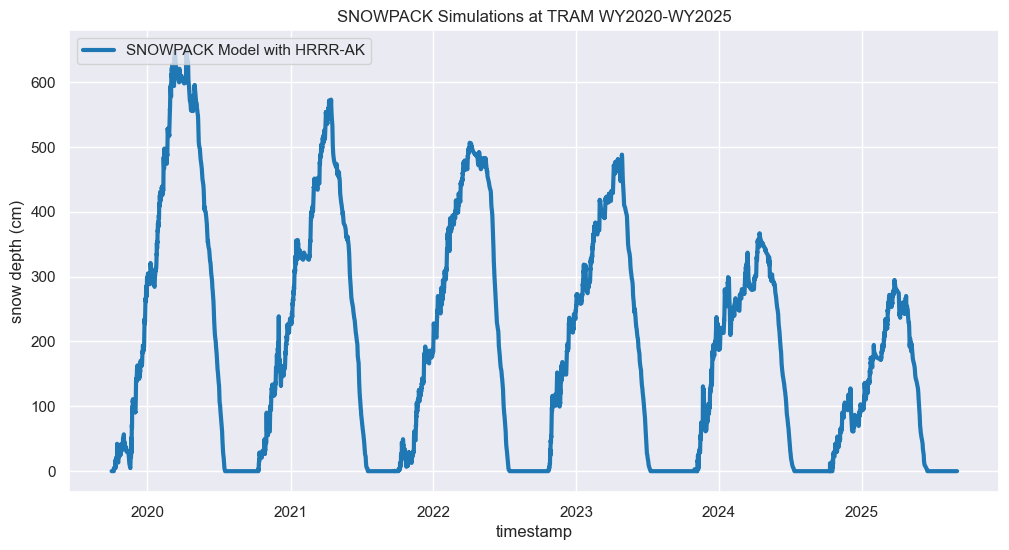

In [8]:
ds_snowpack_hrrrak.HS_mod.plot(label = 'SNOWPACK Model with HRRR-AK', linewidth = 3, color='tab:blue')
# ds_snowpack_met_hrrrak.HS_mod.plot(label = 'SNOWPACK Model with Met (Mixed))', linewidth = 3, color='tab:green')
# ds_snowpack_met_hrrrak_ffill.HS_mod.plot(label = 'SNOWPACK Model with Met (Mixed) + Ffill', linewidth = 3, color='tab:red')

# ds_obs.hs.plot(label = 'Observations', linewidth = 3, color='black')


plt.title('SNOWPACK Simulations at TRAM WY2020-WY2025')
plt.legend(loc='upper left')

# plt.ylim([-10, 300])

plt.ylabel('snow depth (cm)')

# Temporary -- REMOVE OONCE YOU RESAVE THE MET FILE

In [23]:
# filename = '/hdd/snow_hydrology/met_station/tram/JTMA2_MountRoberts_Tram_Synoptic_everything_utc_until_2025-10-08.csv'
filename = '/hdd/snow_hydrology/met_station/tram/JTMA2.2026-03-20.csv' # this one is everything downloaded until 20 March 2026 
df_met = pd.read_csv(filename, sep = ",", low_memory=False, skiprows=10)
df_met['datetime'] = pd.to_datetime(df_met['Date_Time'], utc=True)
# set datetime as the index
df_met = df_met.iloc[1:].copy() # skipping that first row since it's the units row
df_met.set_index('datetime', inplace=True)

# Keep only desired variables and rename them
df_met = df_met[
    [
        'air_temp_set_1',
        'relative_humidity_set_1',
        'wind_speed_set_1', 
        'wind_direction_set_1',
        'snow_depth_set_1',
        'solar_radiation_set_1',
        'precip_accum_set_1'
    ]
].copy()

df_met = df_met.rename(columns={
    'air_temp_set_1': 'temp',
    'relative_humidity_set_1': 'rh',
    'wind_speed_set_1': 'wind', 
    'wind_direction_set_1': 'wind_dir',
    'snow_depth_set_1': 'hs',
    'solar_radiation_set_1': 'solar_rad',
    'precip_accum_set_1': 'precip_accum'
})

# -----------------------------------------------------------------------------
# Convert all variables to numeric
# (forces strings/object columns into floats, invalid values -> NaN)
# -----------------------------------------------------------------------------

for col in df_met.columns:
    df_met[col] = pd.to_numeric(df_met[col], errors='coerce')

# -----------------------------------------------------------------------------
# Fix datetime index
# -----------------------------------------------------------------------------

df_met.index = pd.to_datetime(df_met.index, utc=True)
df_met = df_met.sort_index()

# Remove timezone for xarray compatibility
df_met.index = df_met.index.tz_convert(None)

# -----------------------------------------------------------------------------
# Convert to xarray
# -----------------------------------------------------------------------------

ds_met = xr.Dataset.from_dataframe(df_met)

# Rename index dimension to time
ds_met = ds_met.rename({'datetime': 'time'})

# -----------------------------------------------------------------------------
# Select desired period
# -----------------------------------------------------------------------------

ds_met = ds_met.sel(
    time=slice(
        "2019-10-01T05:00:00",
        "2025-09-30T05:00:00"
    )
)

# -----------------------------------------------------------------------------
# Check result
# -----------------------------------------------------------------------------

ds_met['hs'] = ds_met['hs'] * 0.1
# cleaning qc code (I've never used before)
def qc_range(da, vmin, vmax):
    return da.where((da >= vmin) & (da <= vmax))

ds_met['hs'] = qc_range(ds_met['hs'], 0,300) # in mm, converted to cm above 

Text(0, 0.5, 'snow depth (cm)')

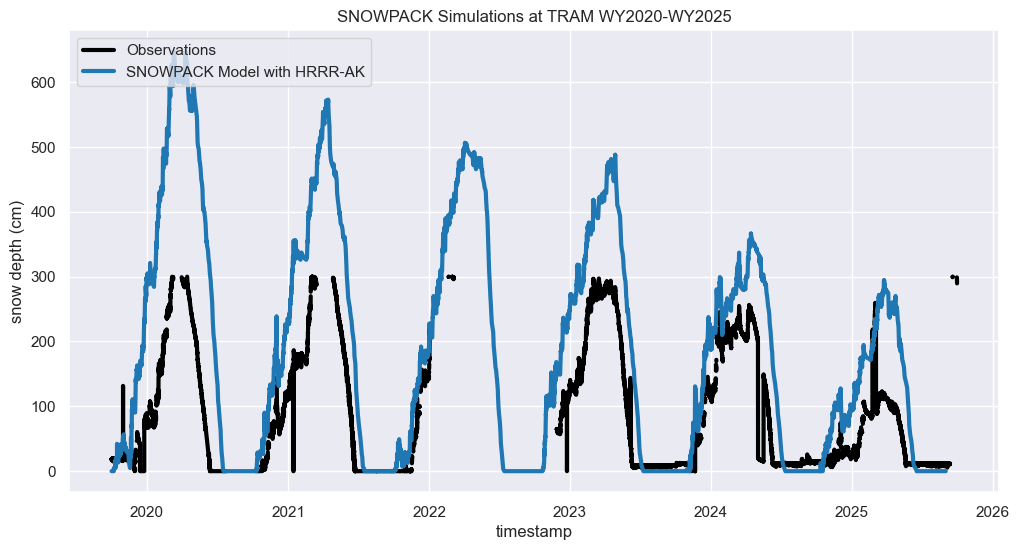

In [24]:
ds_met.hs.plot(label = 'Observations', linewidth = 3, color='black')

ds_snowpack_hrrrak.HS_mod.plot(label = 'SNOWPACK Model with HRRR-AK', linewidth = 3, color='tab:blue')
# ds_snowpack_met_hrrrak.HS_mod.plot(label = 'SNOWPACK Model with Met (Mixed))', linewidth = 3, color='tab:green')
# ds_snowpack_met_hrrrak_ffill.HS_mod.plot(label = 'SNOWPACK Model with Met (Mixed) + Ffill', linewidth = 3, color='tab:red')



plt.title('SNOWPACK Simulations at TRAM WY2020-WY2025')
plt.legend(loc='upper left')

# plt.ylim([-10, 300])

plt.ylabel('snow depth (cm)')

### SWE

Text(0, 0.5, 'SWE (mm)')

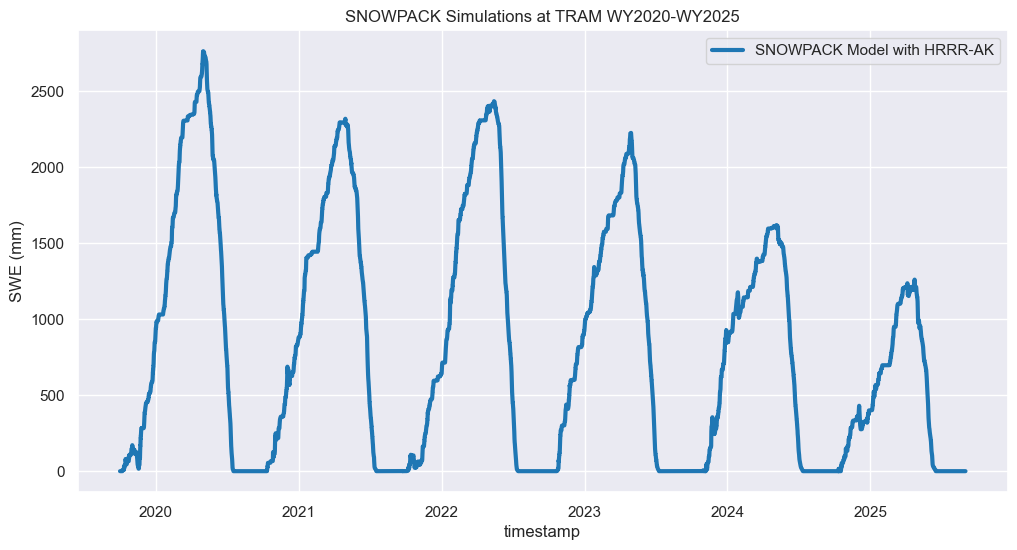

In [8]:
ds_snowpack_hrrrak.SWE.plot(label = 'SNOWPACK Model with HRRR-AK', linewidth = 3, color='tab:blue')
# ds_snowpack_met_hrrrak.SWE.plot(label = 'SNOWPACK Model with Met (Mixed))', linewidth = 3, color='tab:green')
# ds_snowpack_met_hrrrak_ffill.SWE.plot(label = 'SNOWPACK Model with Met (Mixed) + Ffill', linewidth = 3, color='tab:red')

# (ds_obs.swe*10).plot(label = 'Observations', linewidth = 3, color='black') # convert SWE to mm 


plt.title('SNOWPACK Simulations at TRAM WY2020-WY2025')
plt.legend()

# plt.ylim([-10, 300])

plt.ylabel('SWE (mm)')

Yeah, that kinda anwsers my questions...